<a href="https://colab.research.google.com/github/SANTHOSH-C08/AI-INTERNSHIP/blob/main/crun_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/Churn_Modelling.csv')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [ ]:
df.isna()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isna().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


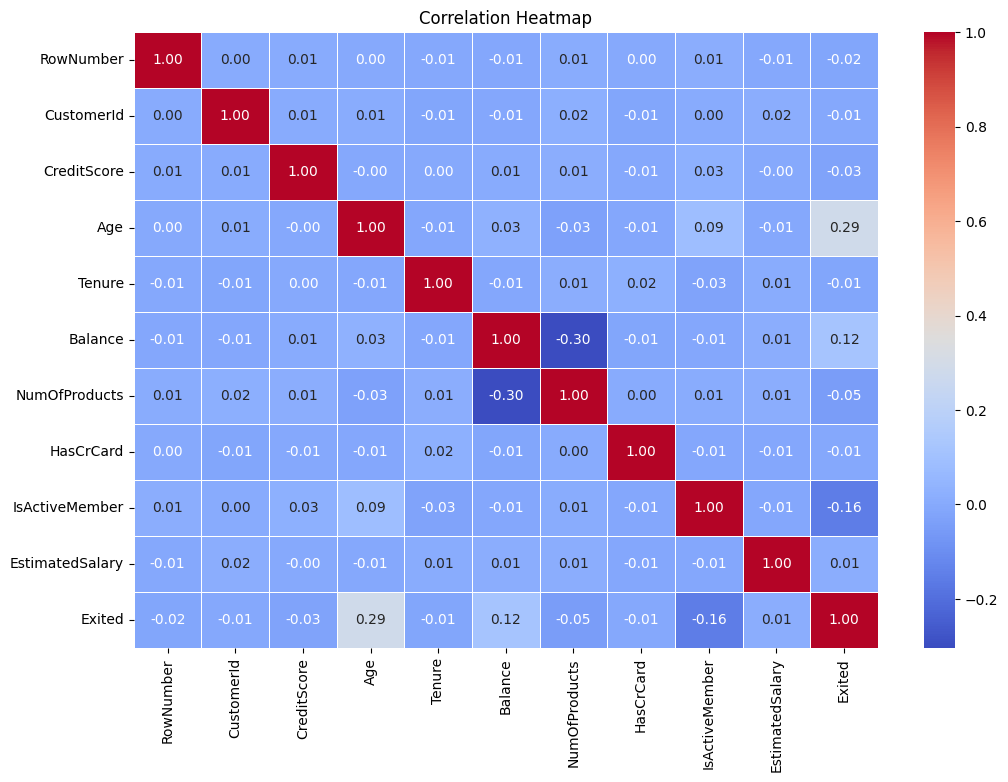

In [ ]:
correlation = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

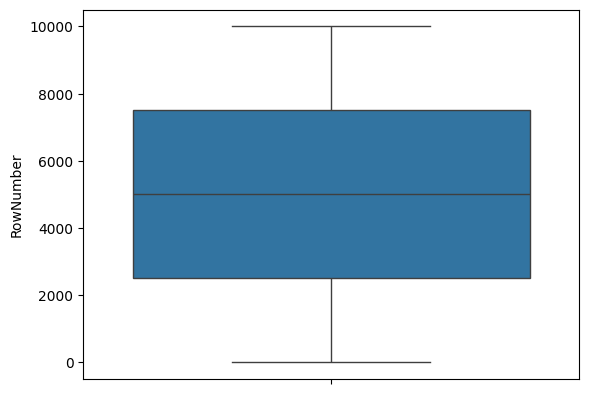

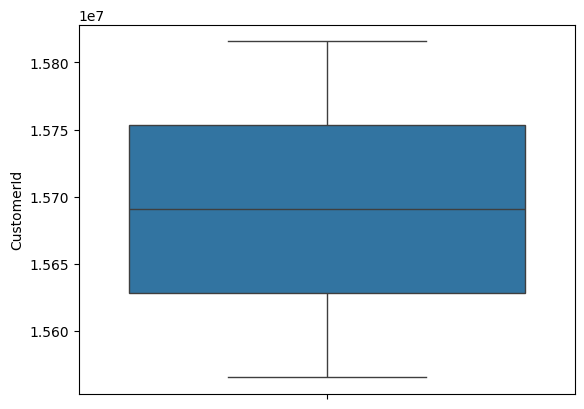

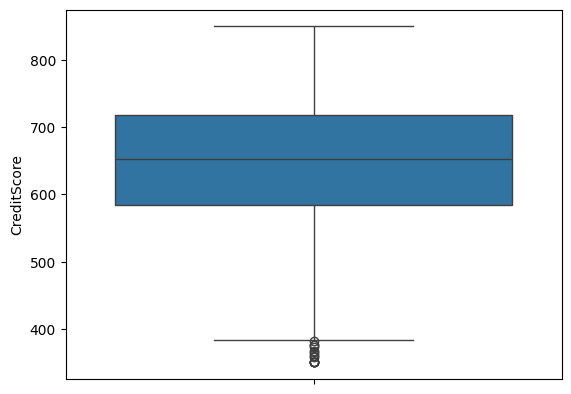

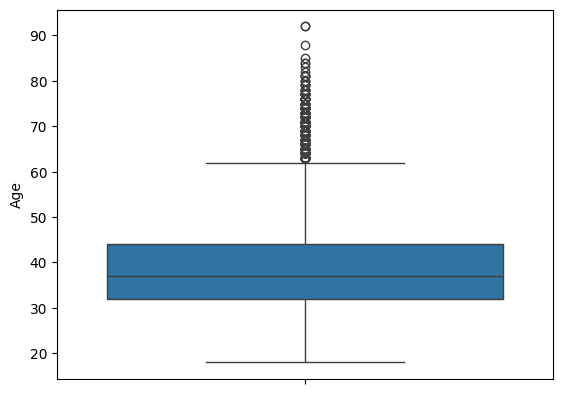

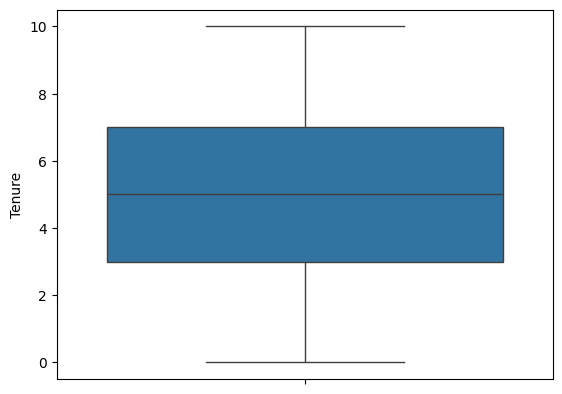

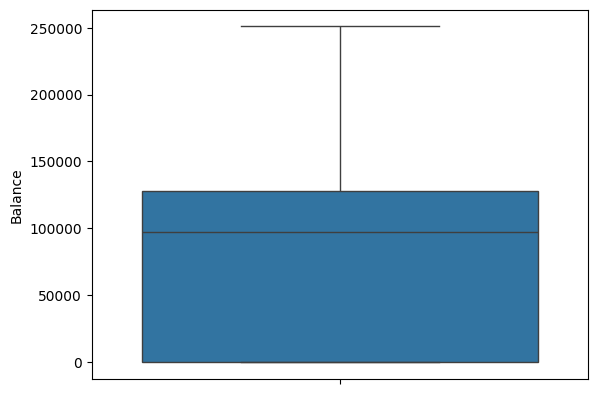

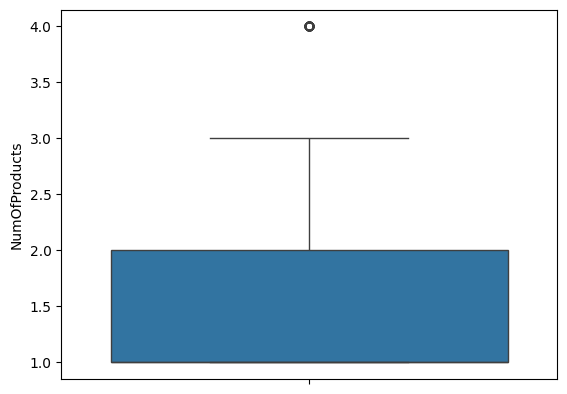

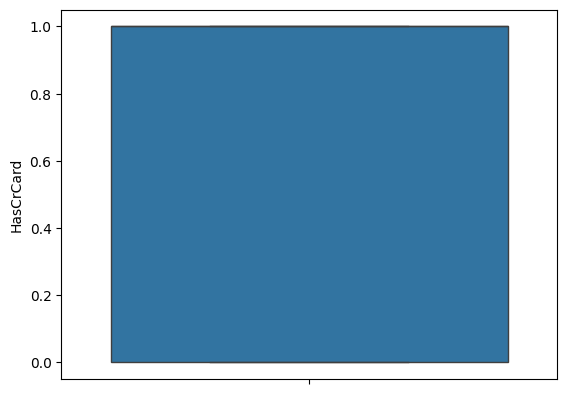

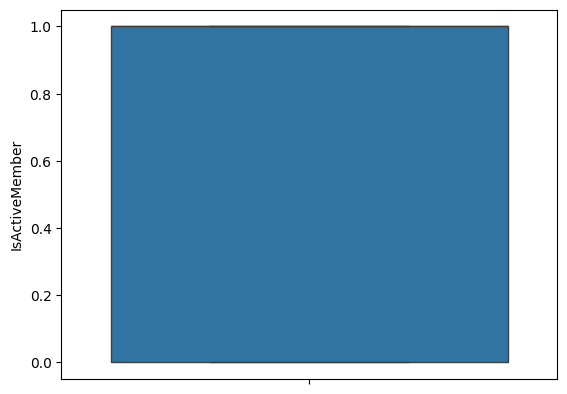

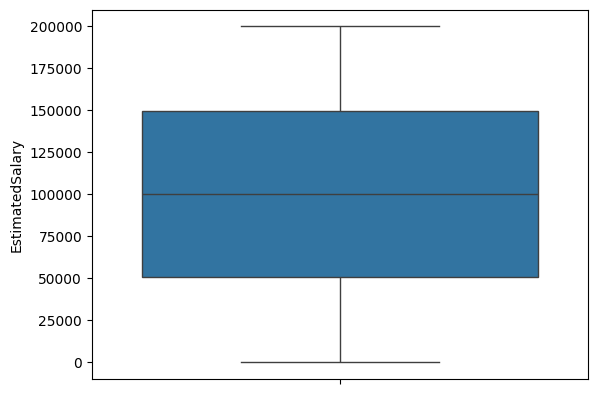

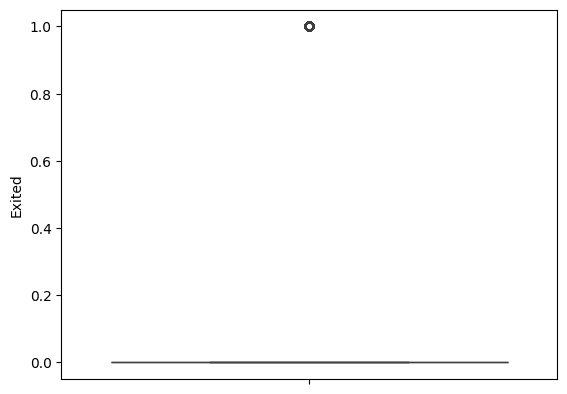

In [ ]:
for i in df.columns:
  if df[i].dtypes !="object":
    sns.boxplot(df[i])
    plt.show()

In [ ]:
col=['CreditScore','Age','NumOfProducts']

In [ ]:
for i in col:
  q1=df[i].quantile(0.25)
  q3=df[i].quantile(0.75)
  iqr=q3-q1
  lf=q1-1.5*iqr
  uf=q3+1.5*iqr
  df=df[(lf <= df[i]) & (uf >= df[i])]

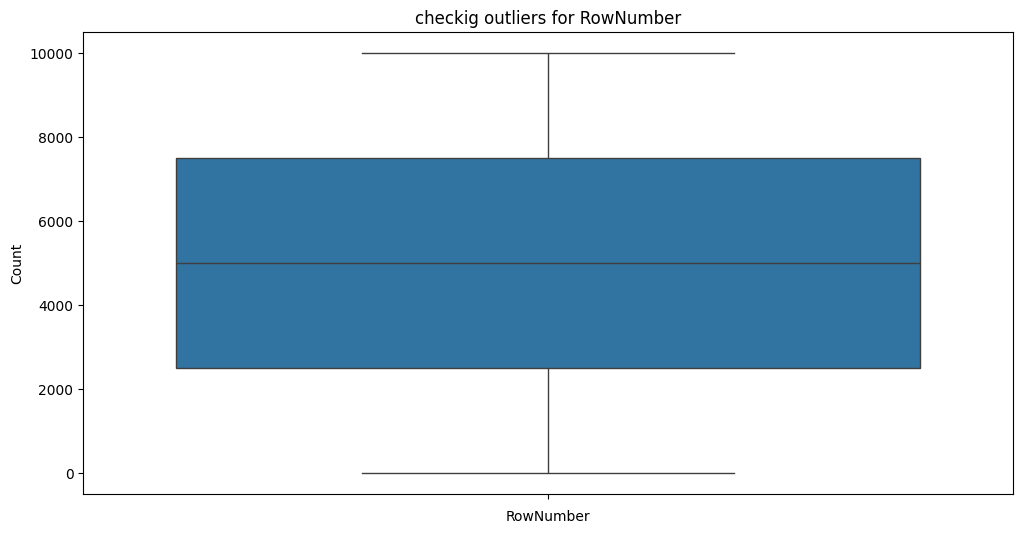

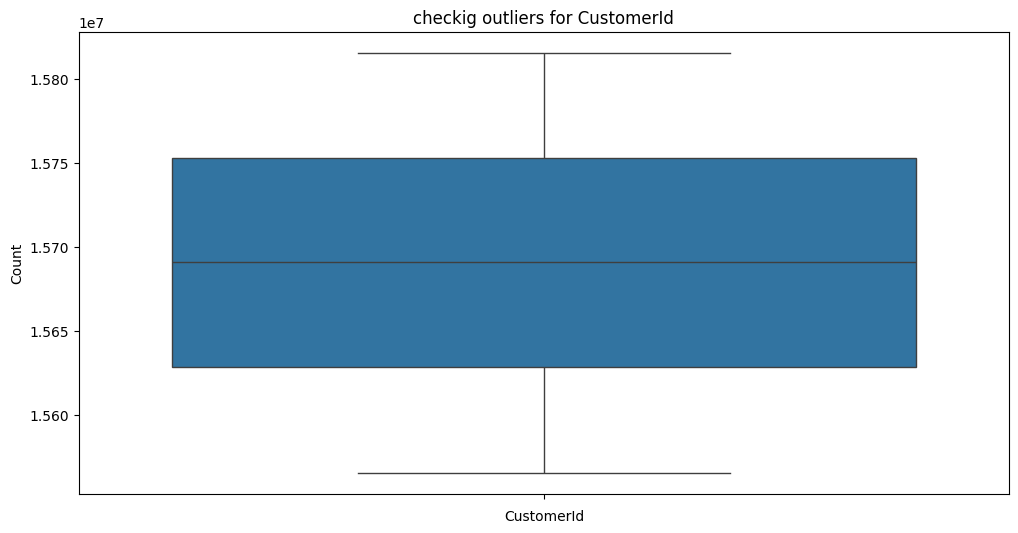

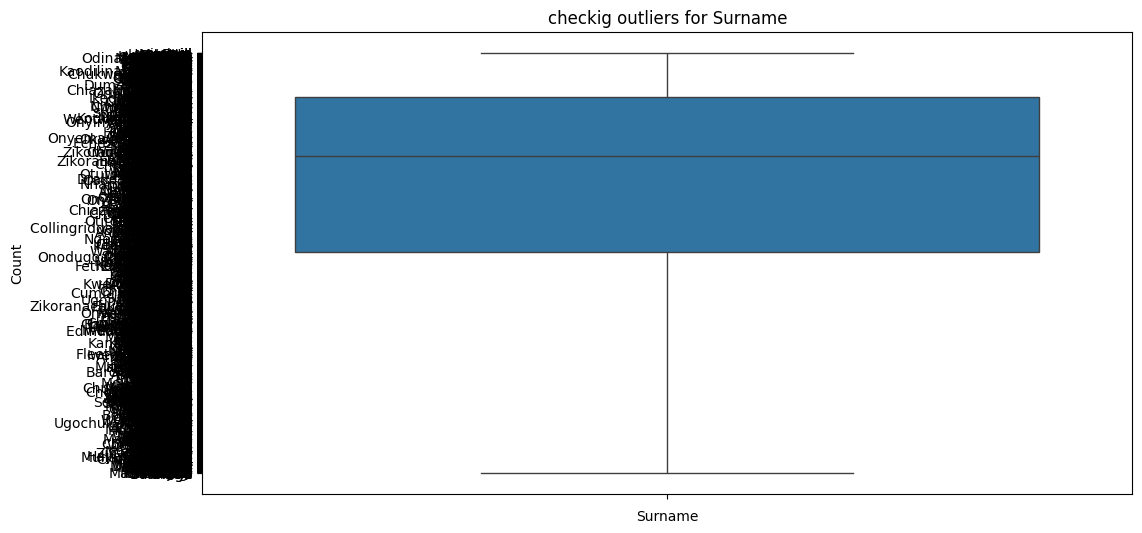

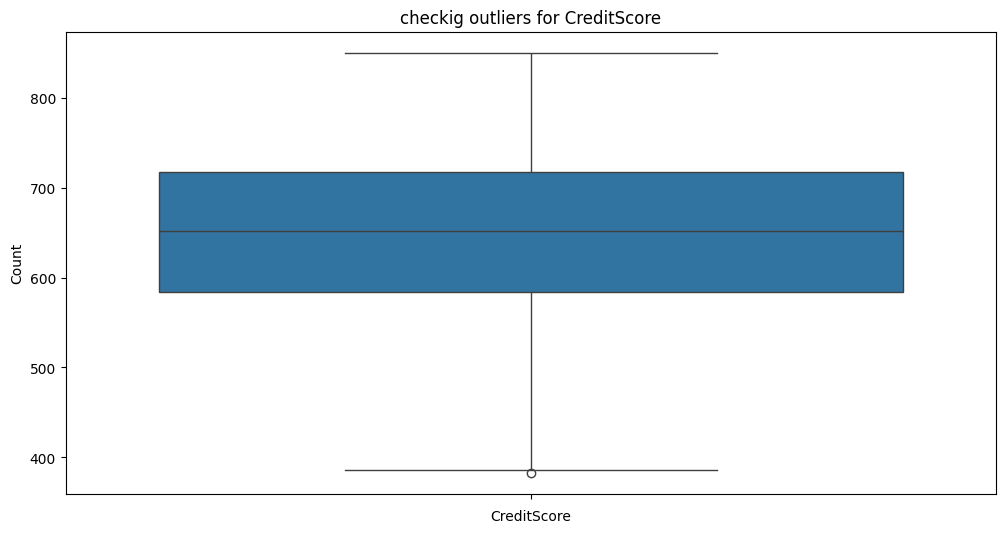

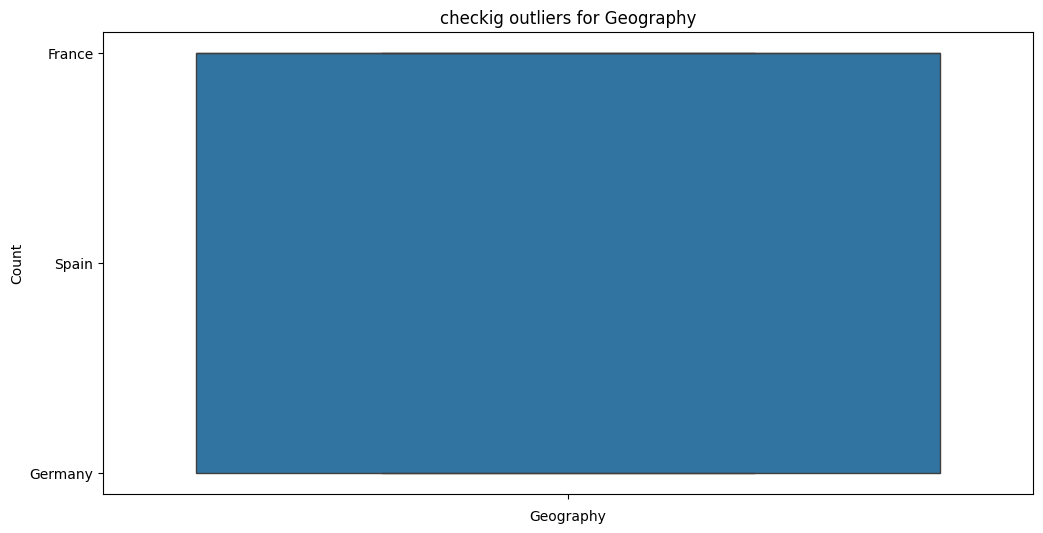

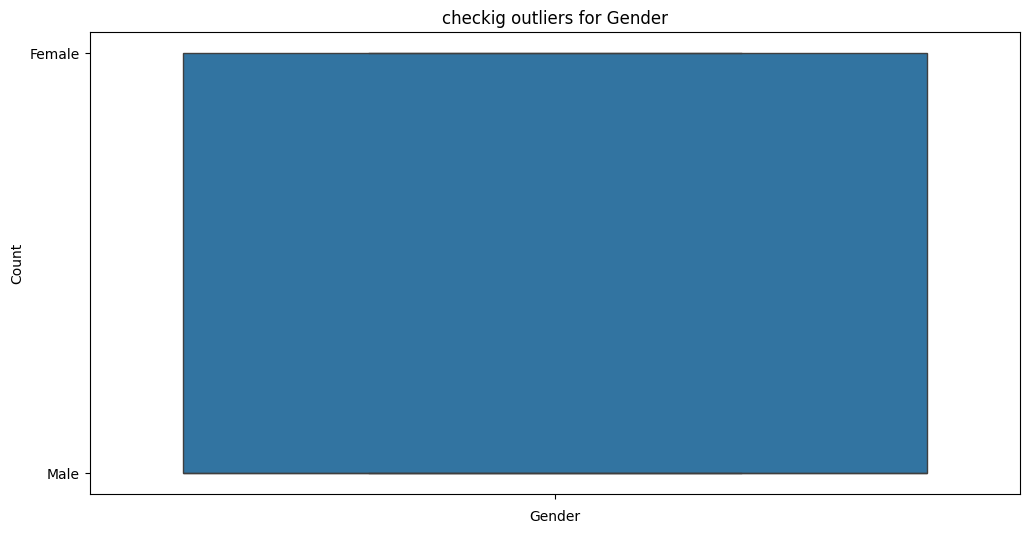

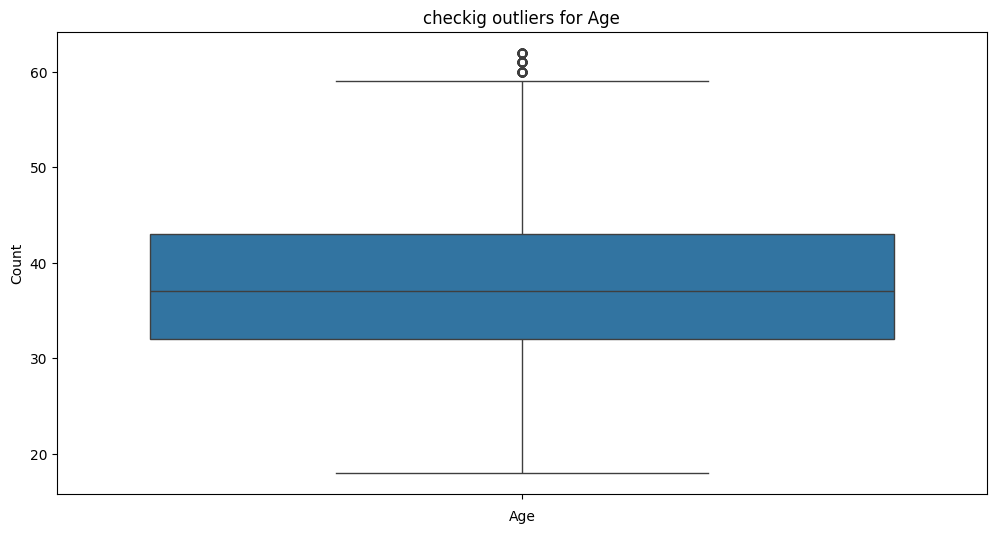

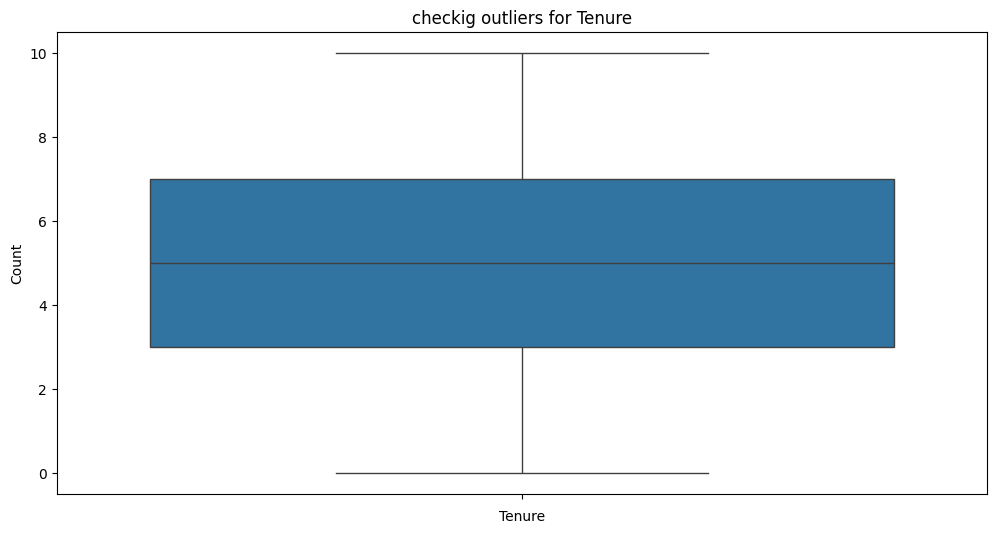

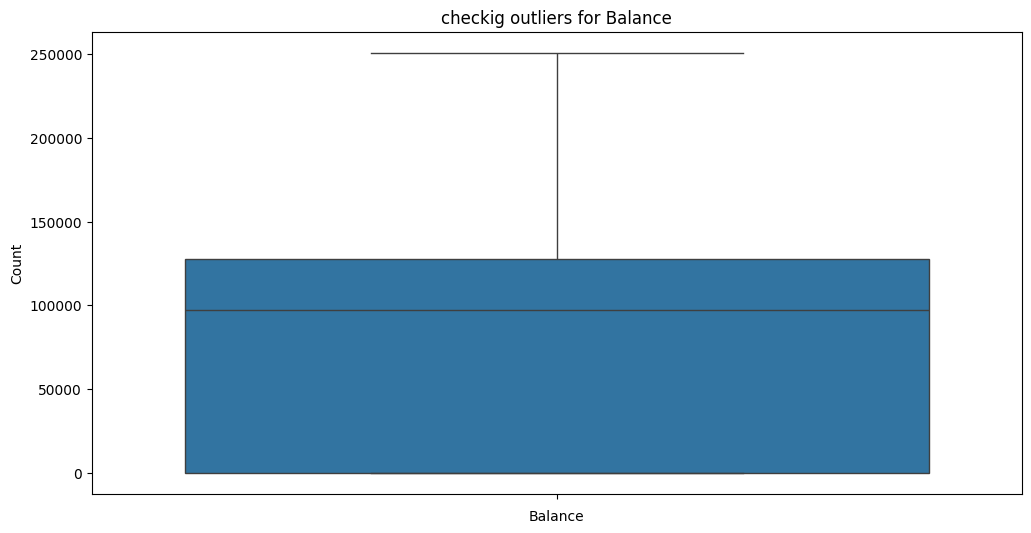

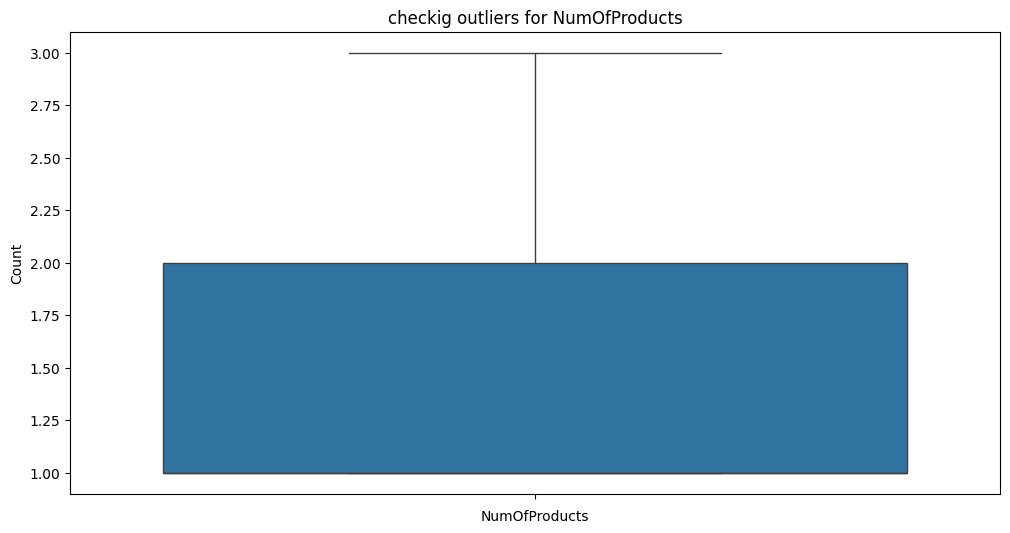

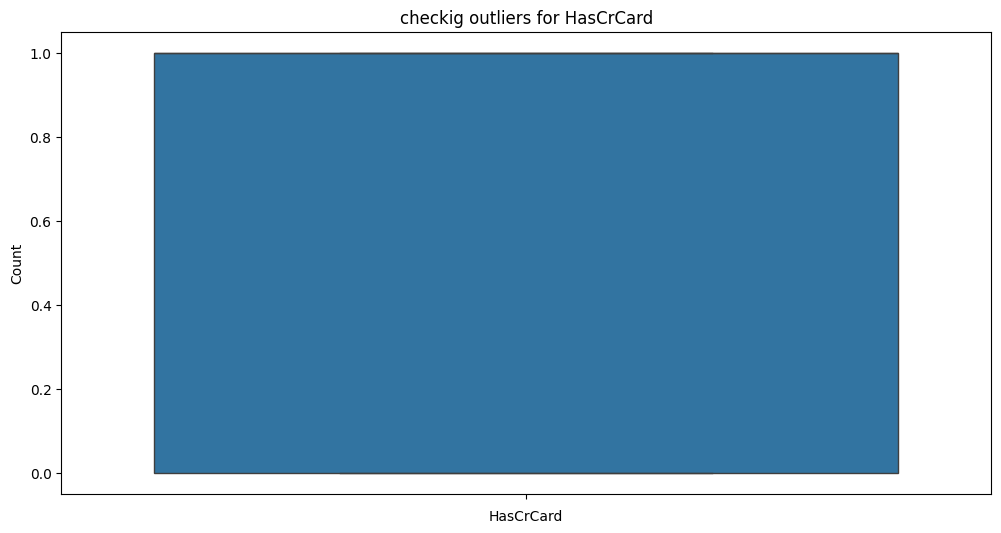

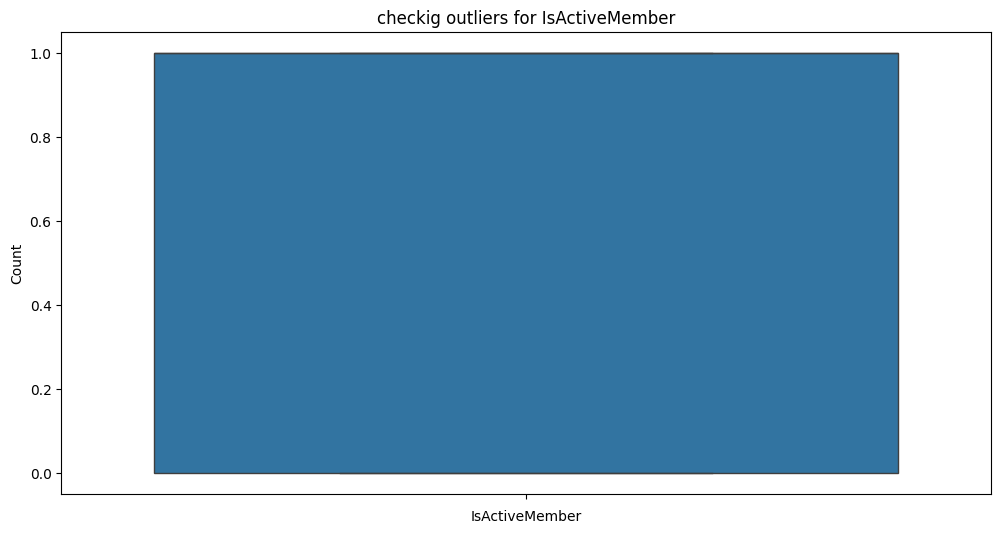

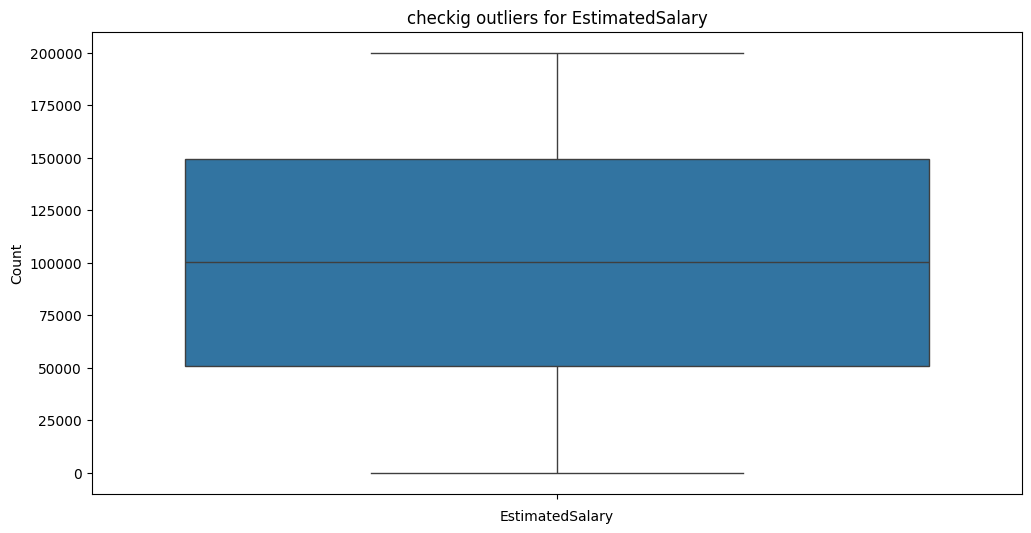

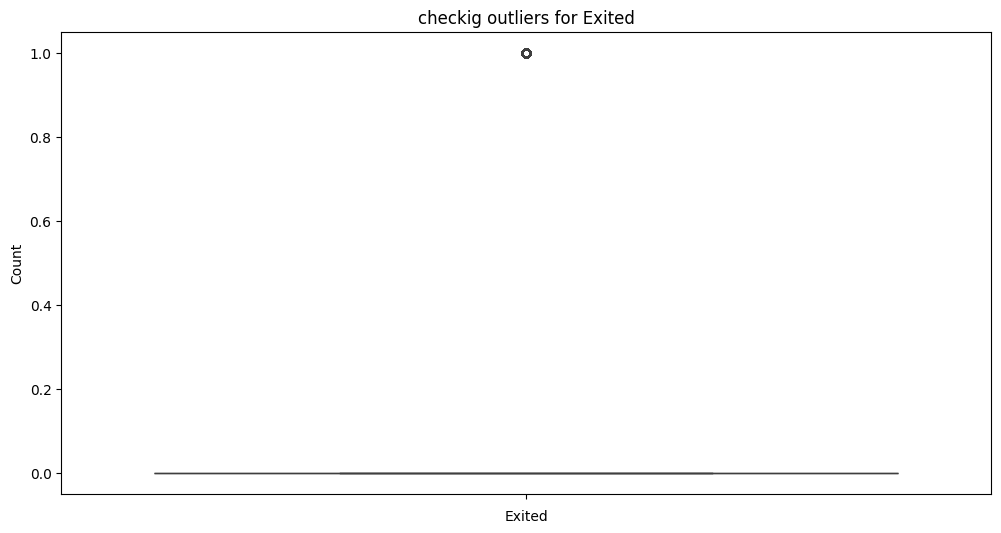

In [ ]:
for i in df.columns:
    plt.figure(figsize = (12,6))
    sns.boxplot(df[i])
    plt.title(f"checkig outliers for {i}")
    plt.xlabel(i)
    plt.ylabel("Count")
    plt.show()

In [ ]:
col=['Age']

In [ ]:
for i in col:
  q1=df[i].quantile(0.25)
  q3=df[i].quantile(0.75)
  iqr=q3-q1
  lf=q1-1.5*iqr
  uf=q3+1.5*iqr
  df=df[(lf <= df[i]) & (uf >= df[i])]

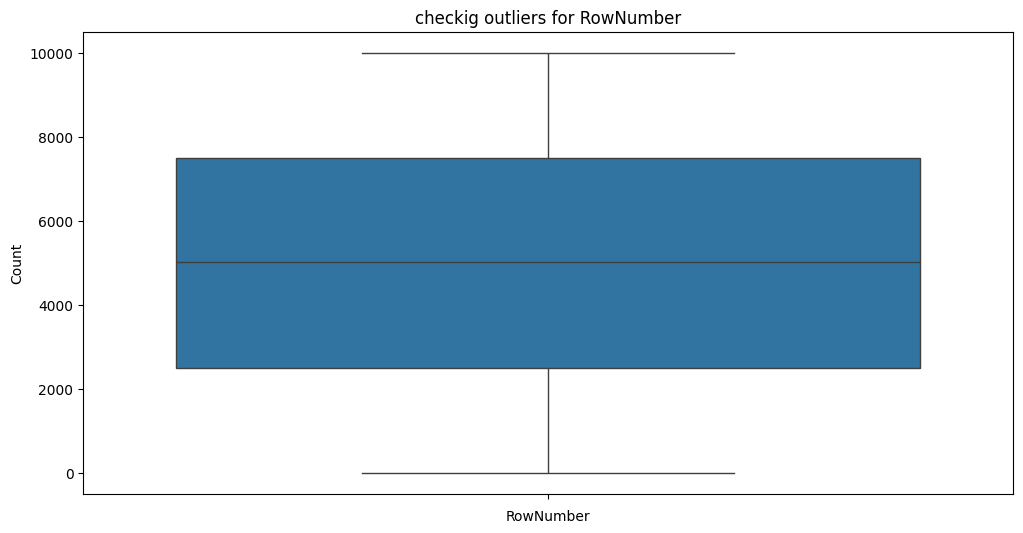

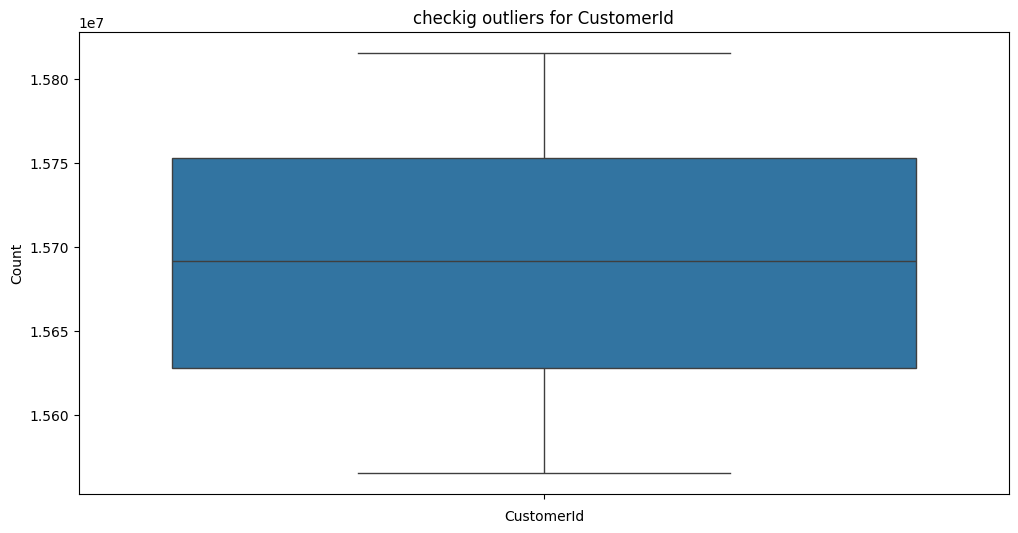

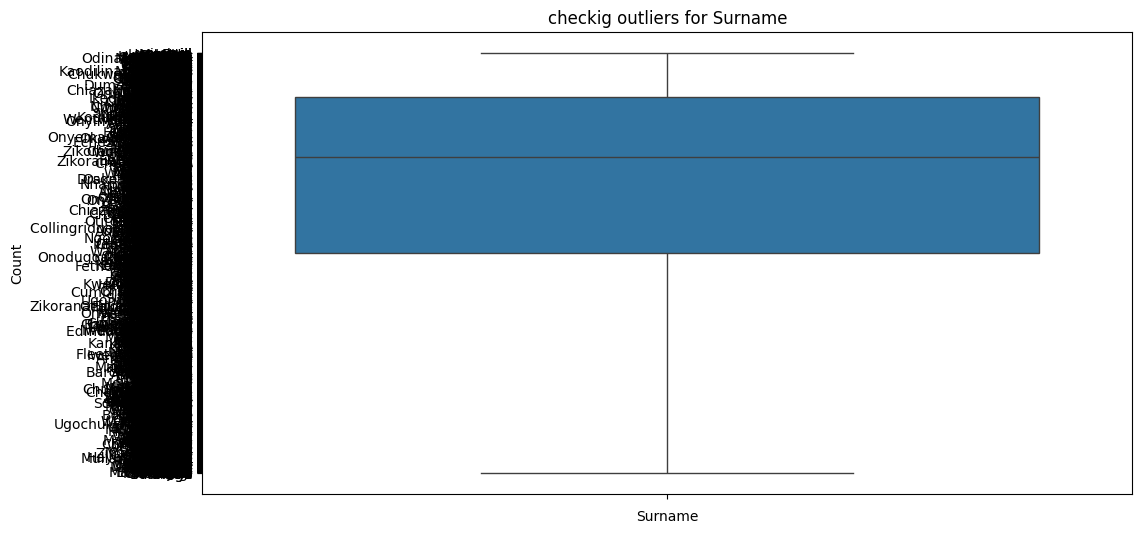

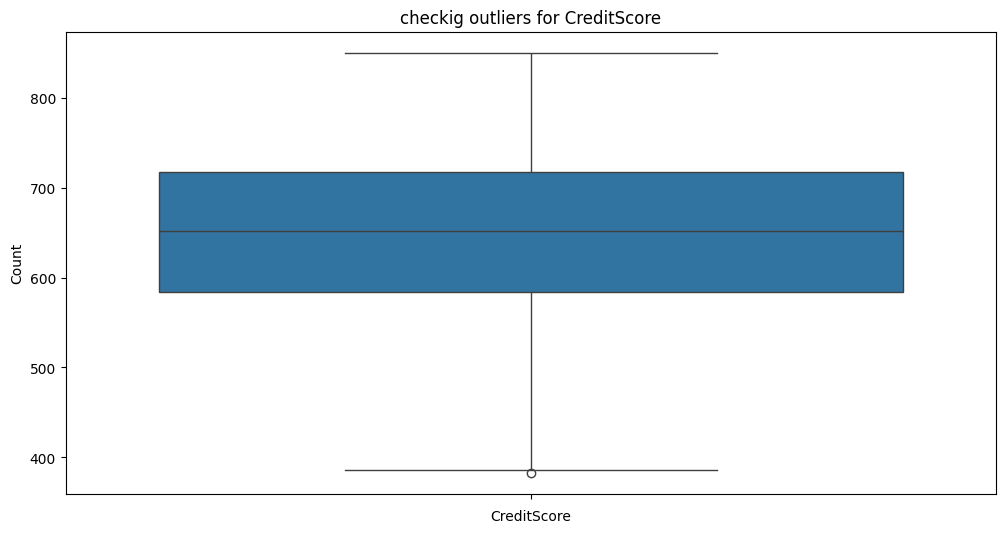

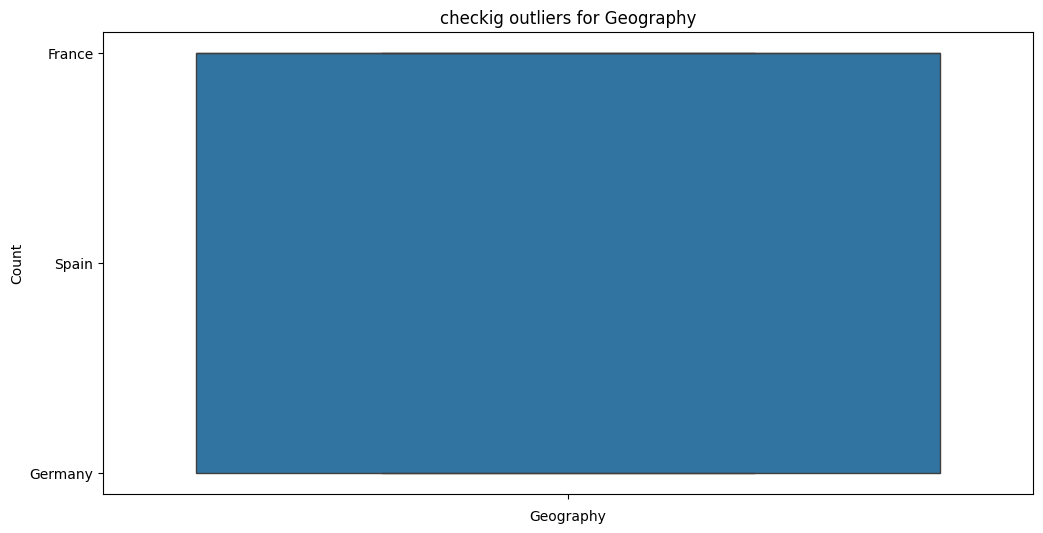

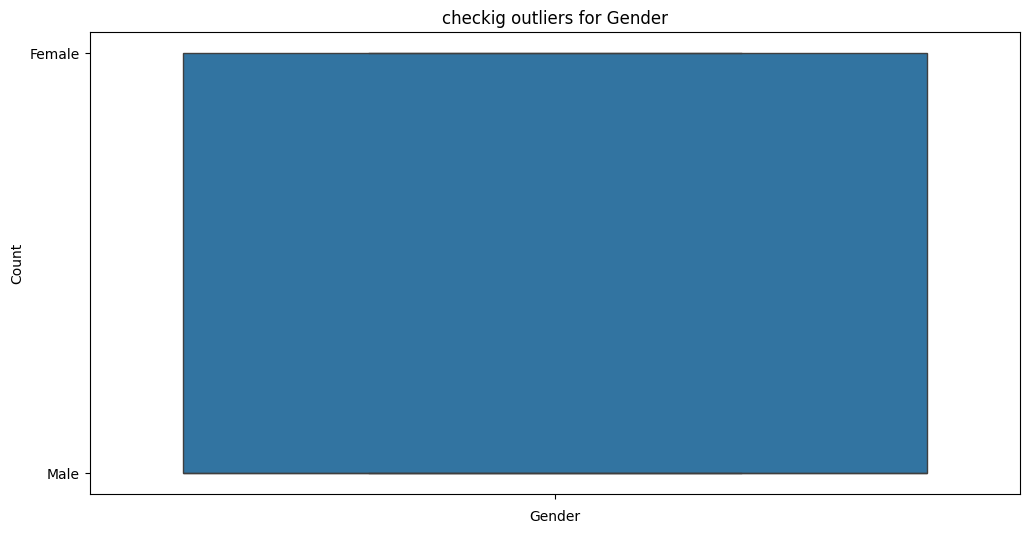

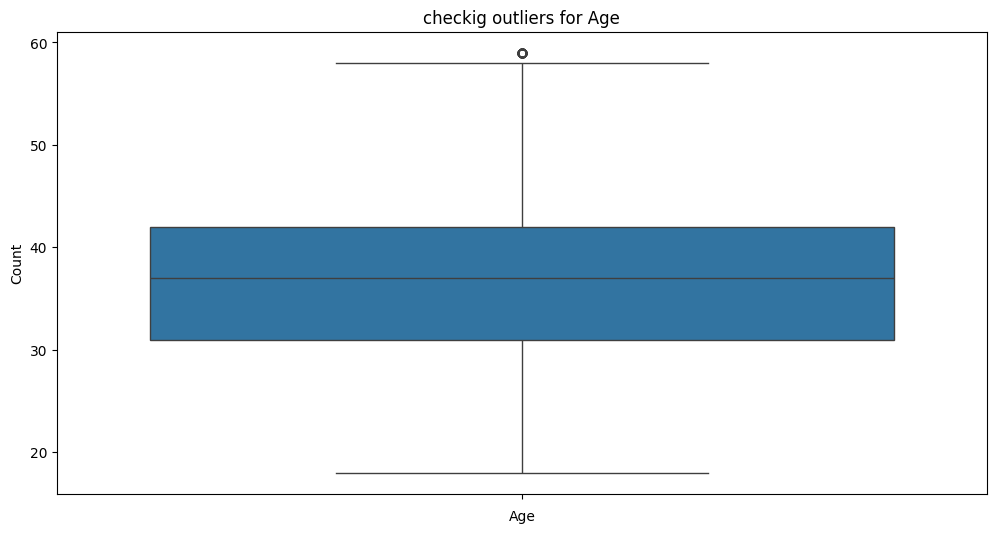

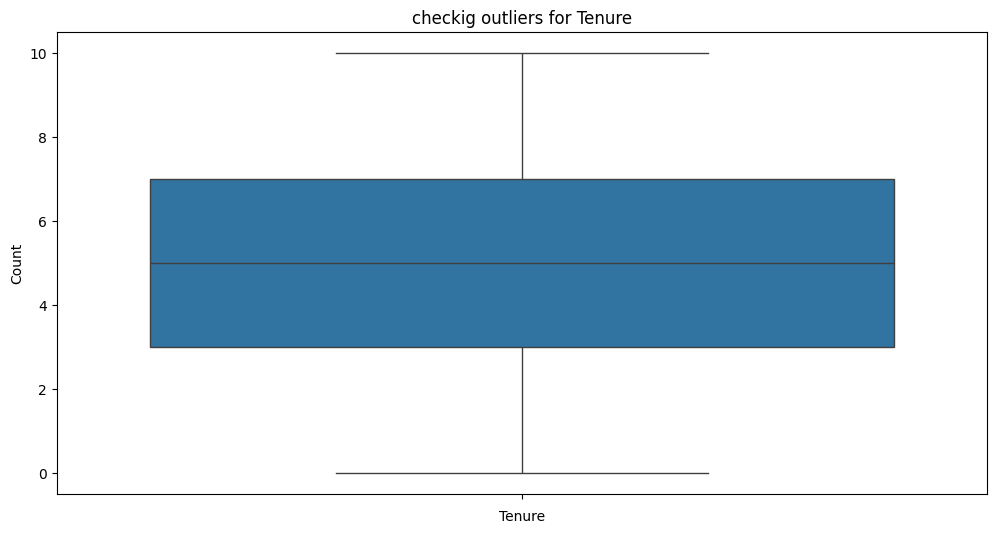

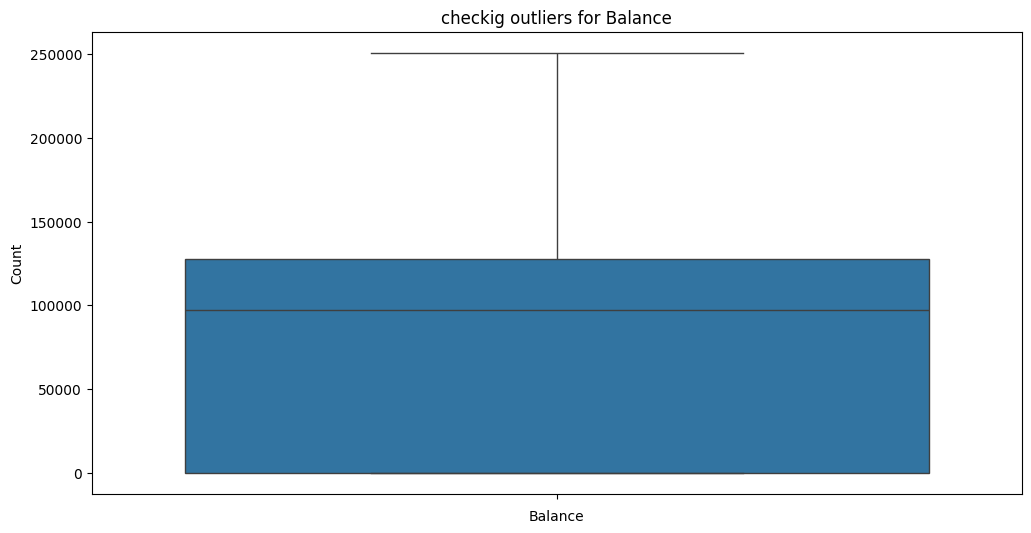

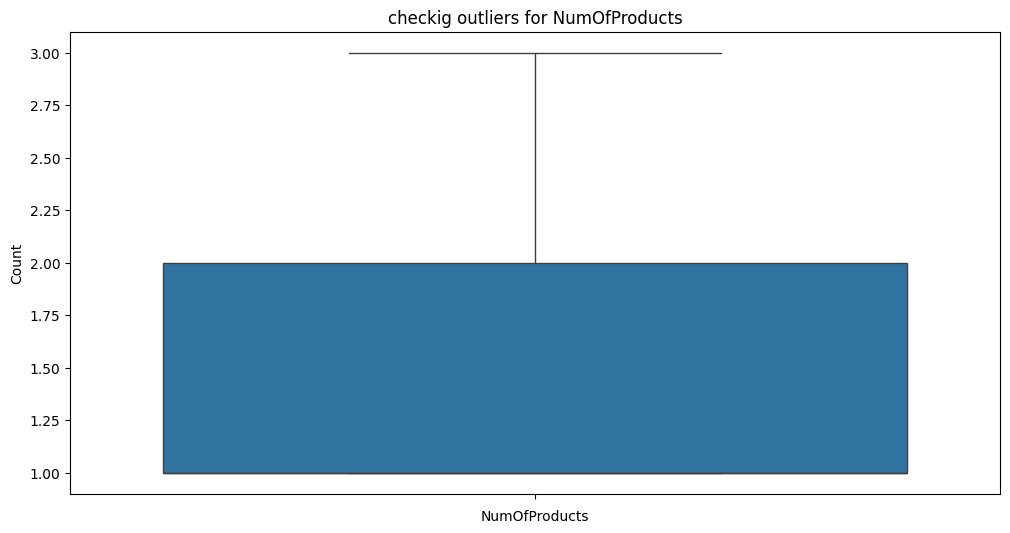

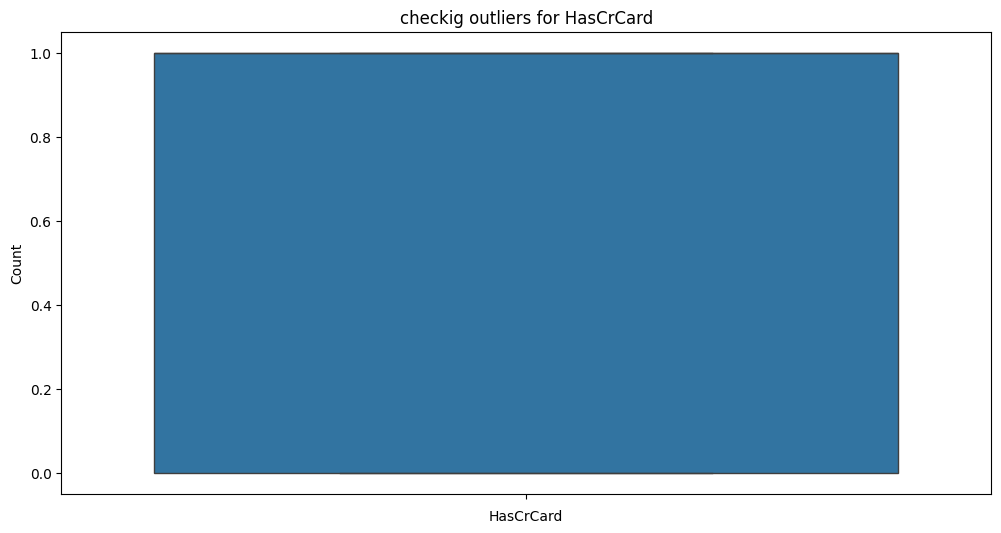

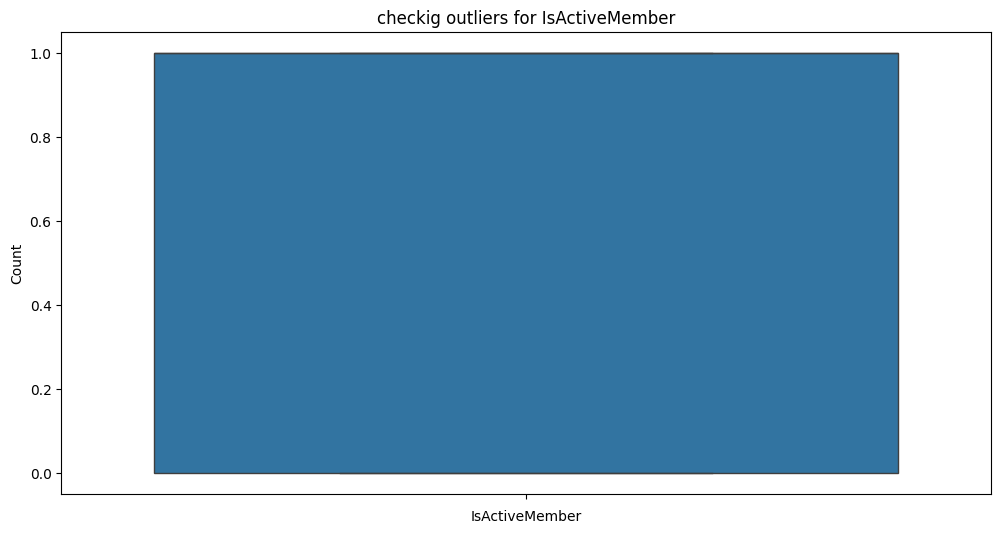

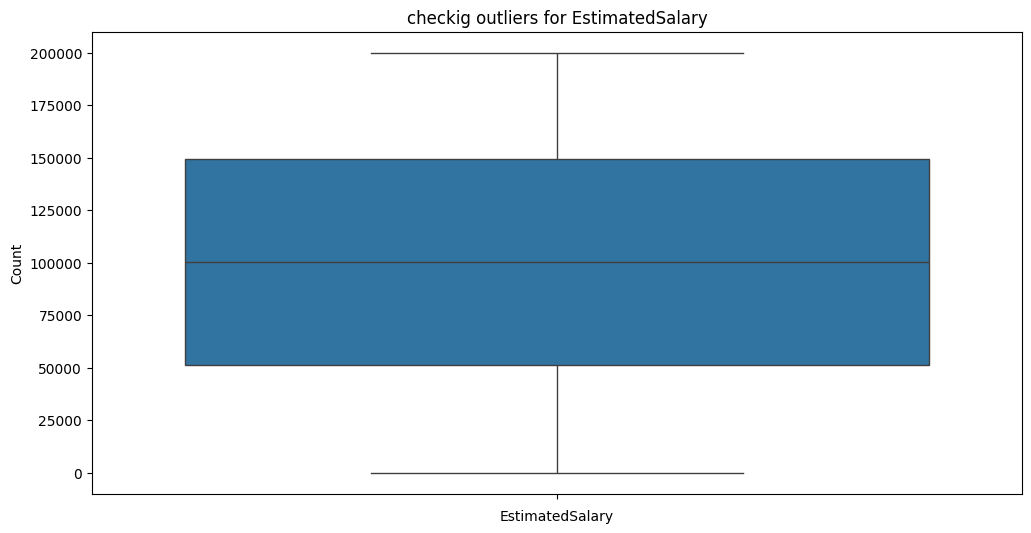

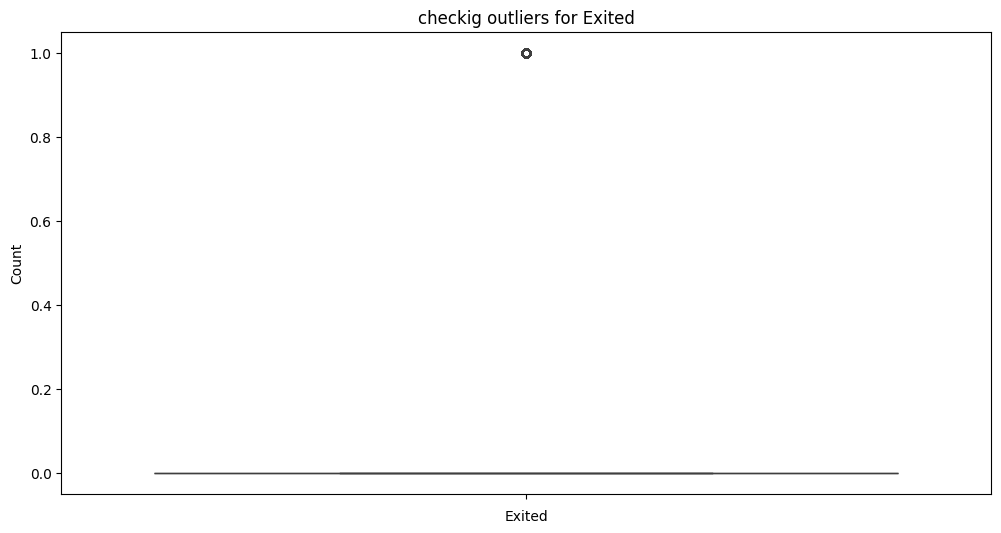

In [ ]:
for i in df.columns:
    plt.figure(figsize = (12,6))
    sns.boxplot(df[i])
    plt.title(f"checkig outliers for {i}")
    plt.xlabel(i)
    plt.ylabel("Count")
    plt.show()

In [ ]:
col=['Age']

In [ ]:
for i in col:
  q1=df[i].quantile(0.25)
  q3=df[i].quantile(0.75)
  iqr=q3-q1
  lf=q1-1.5*iqr
  uf=q3+1.5*iqr
  df=df[(lf <= df[i]) & (uf >= df[i])]

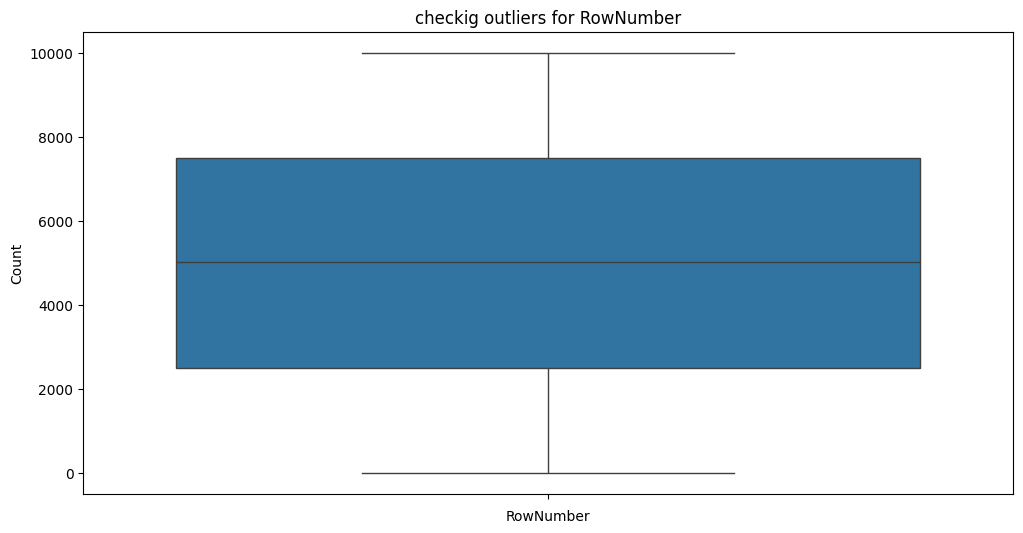

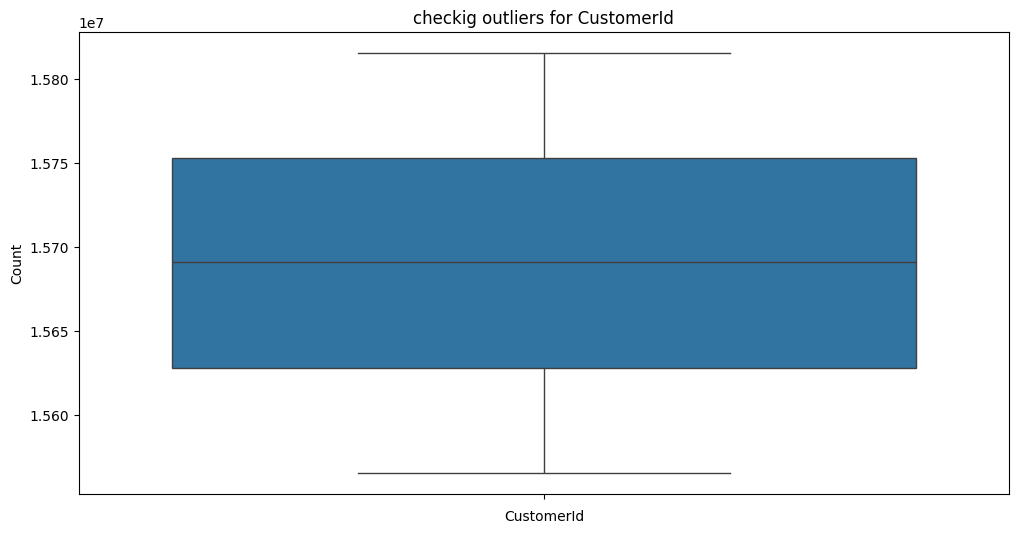

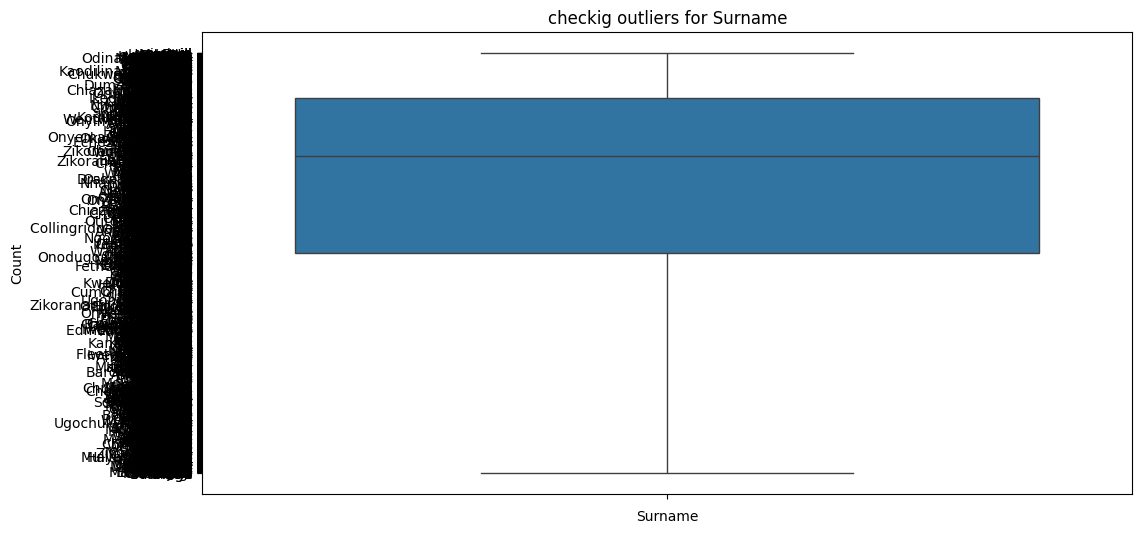

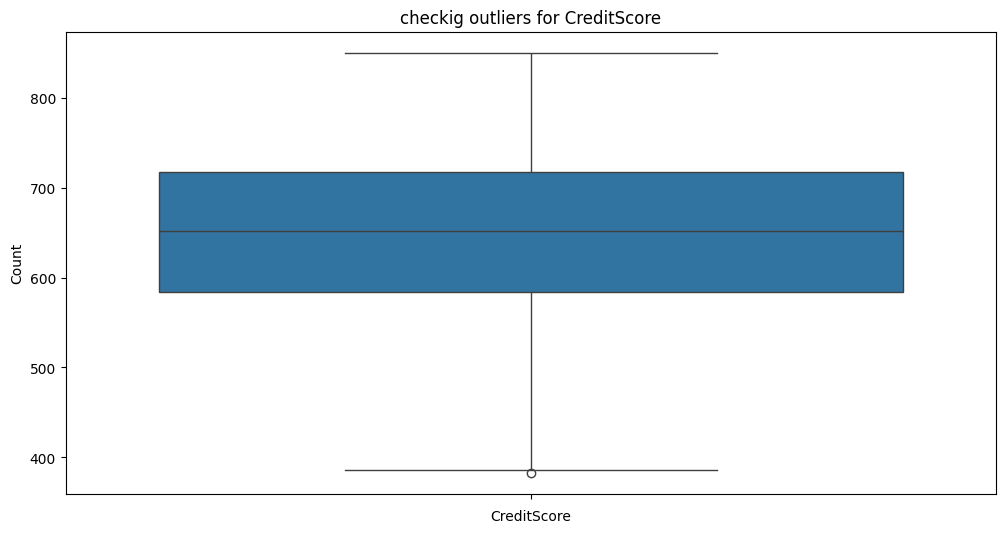

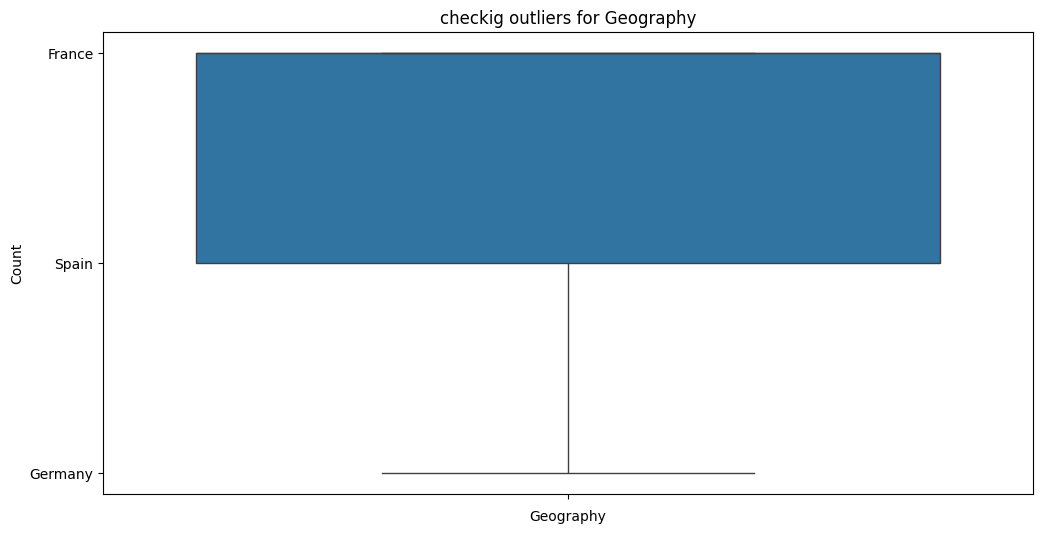

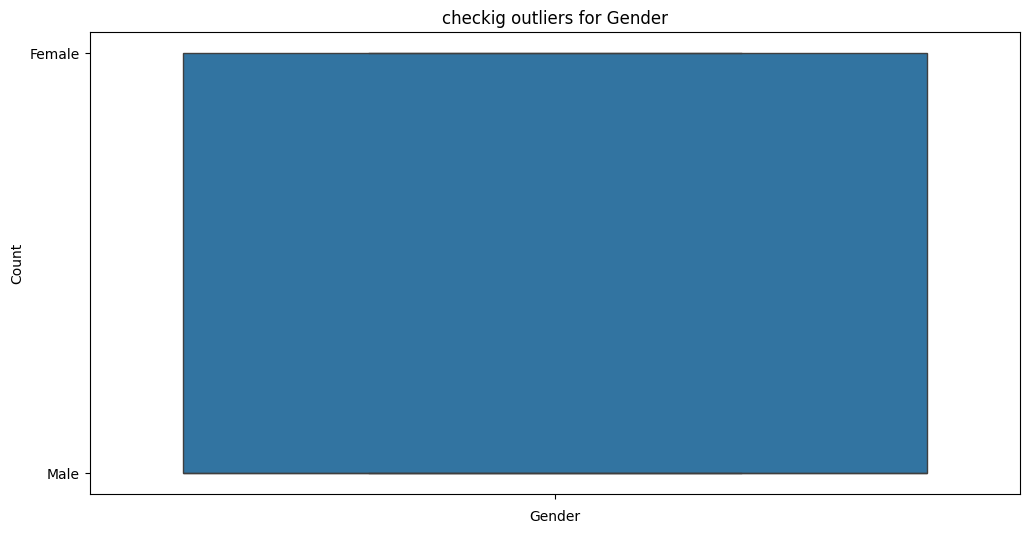

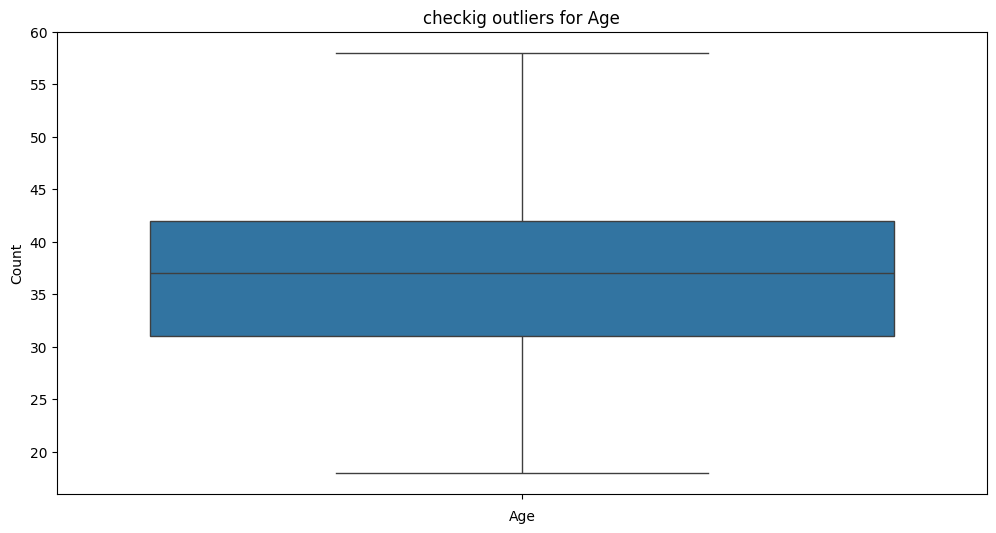

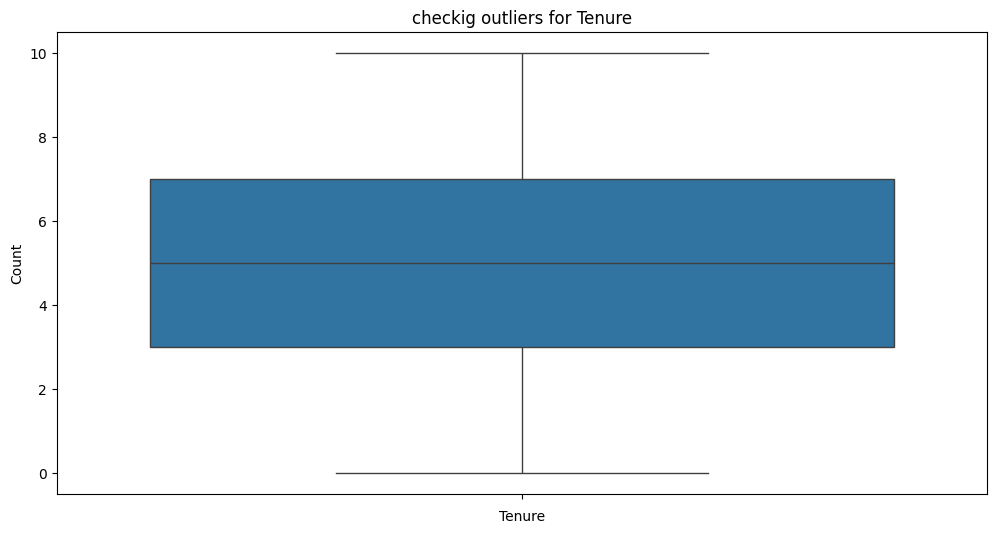

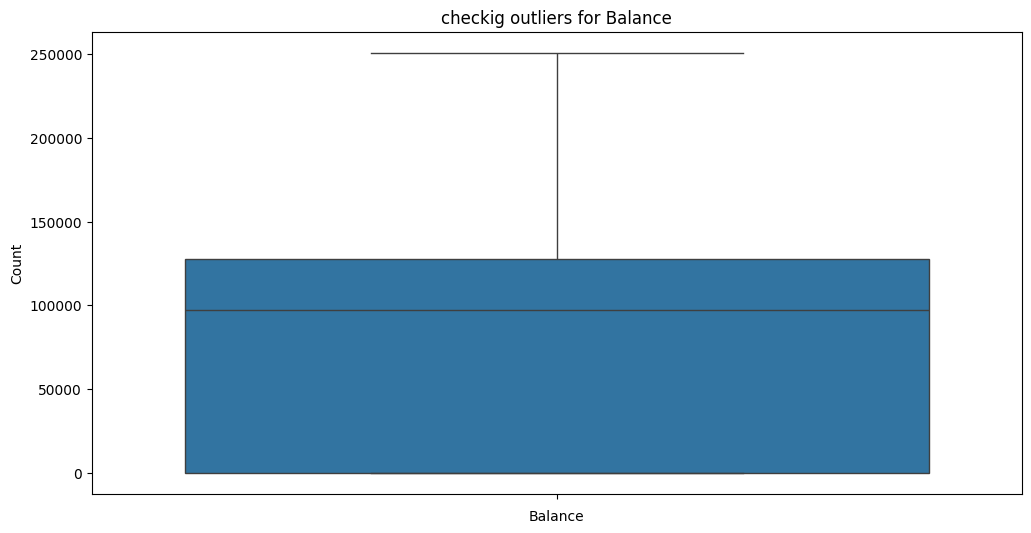

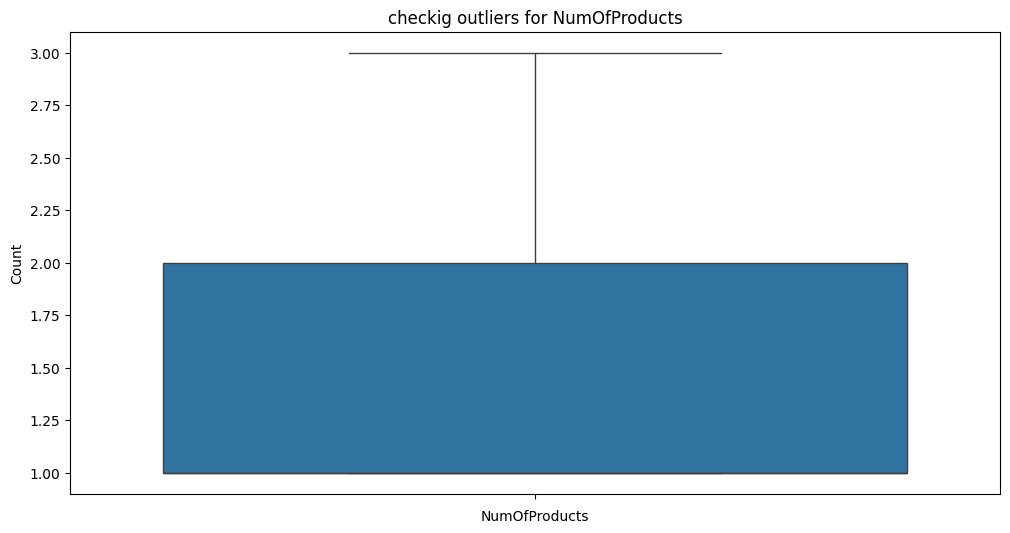

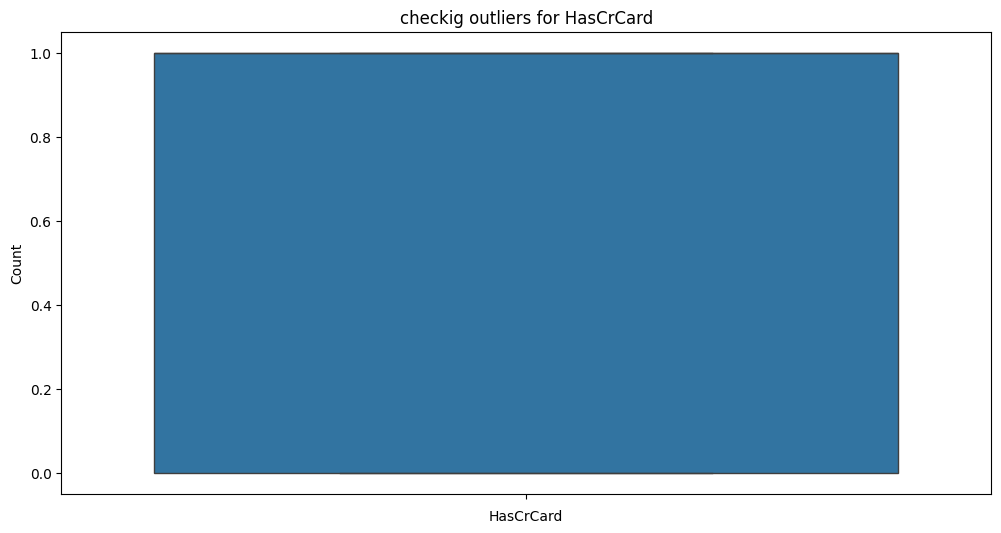

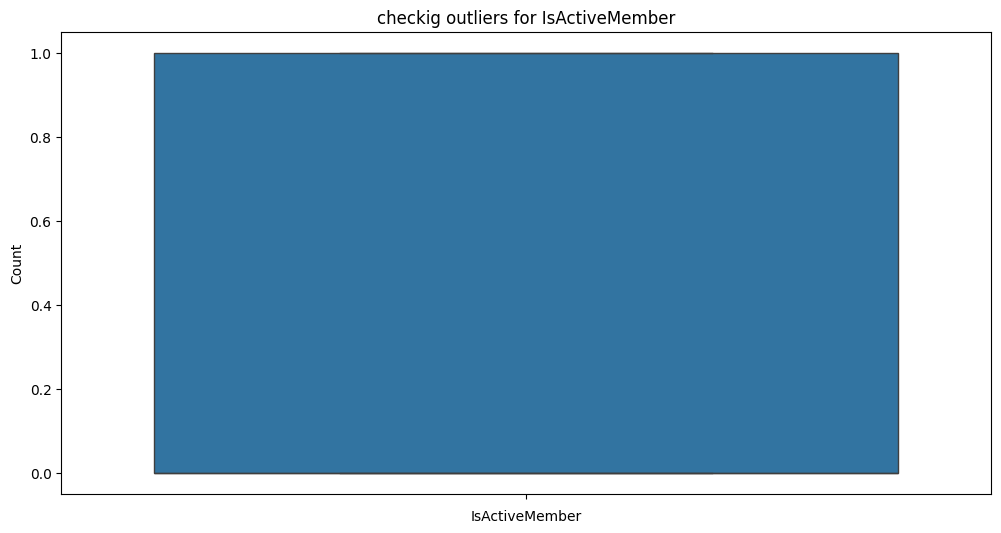

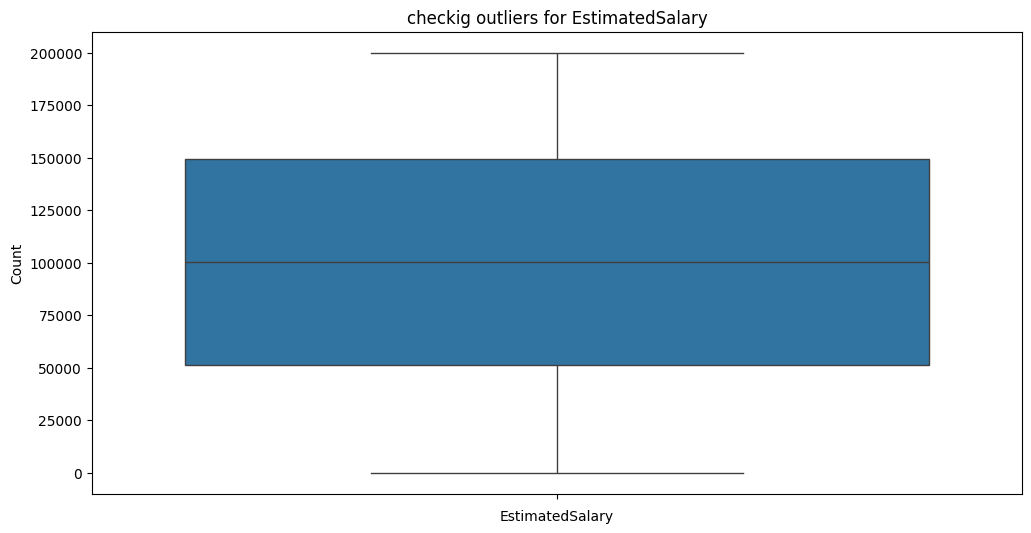

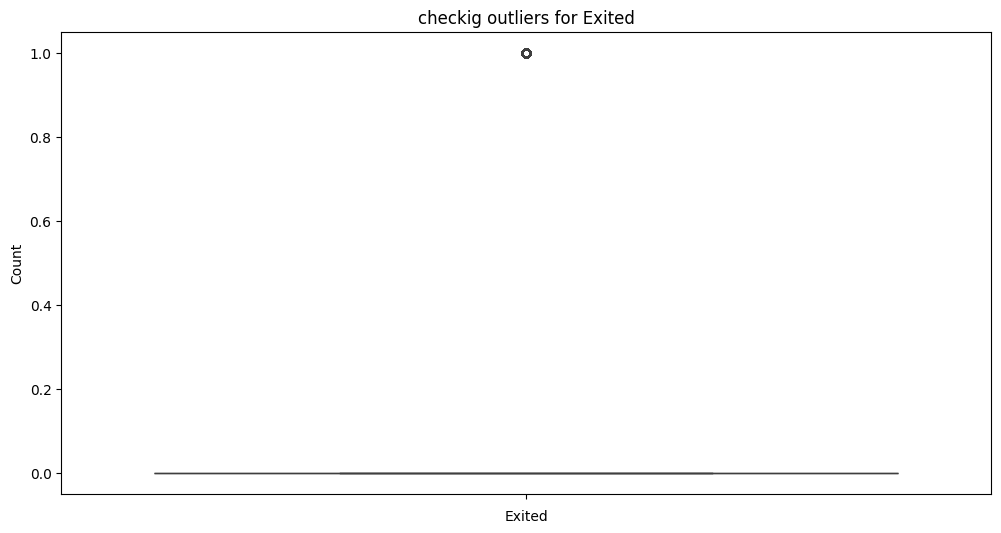

In [ ]:
for i in df.columns:
    plt.figure(figsize = (12,6))
    sns.boxplot(df[i])
    plt.title(f"checkig outliers for {i}")
    plt.xlabel(i)
    plt.ylabel("Count")
    plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in df.columns:
  if df[i].dtypes=='object':
    df[i]=le.fit_transform(df[i])

In [ ]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,1077,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,1136,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,1970,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,281,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,1759,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,1929,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,1293,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,1517,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,2261,772,1,1,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
x = df.iloc[:,:-1]
y = df["Exited"]

In [ ]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2 , random_state=42)

In [ ]:
x_train

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
4347,4348,15645271,2147,615,1,1,24,8,108528.07,2,0,0,179488.41
8907,8908,15710671,999,786,0,1,34,3,137361.96,1,0,0,183682.09
6664,6665,15667632,244,703,0,0,42,7,0.00,2,0,1,72500.68
9493,9494,15617657,2555,664,0,0,36,0,103502.22,1,1,1,146191.82
2612,2613,15588446,2577,550,2,1,34,3,0.00,2,0,0,131281.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6138,6139,15717984,1536,477,0,1,47,9,144900.58,1,1,0,61315.37
5563,5564,15724684,2455,610,2,1,46,5,91897.80,1,1,0,54394.28
5779,5780,15723950,1408,684,2,1,40,2,70291.02,1,1,1,115468.84
911,912,15746490,2738,648,2,0,53,6,111201.41,1,1,1,121542.29


In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
nb=GaussianNB()
nb.fit(x_train,y_train)
y_pred=nb.predict(x_test)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
from sklearn.metrics import accuracy_score
print("Performance of my model:", accuracy_score(y_test, y_pred)*100)


Performance of my model: 82.1294810058855
